# COGS 108 - NBA Players Height and Achievements

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [  ] YES - make available
* [ X ] NO - keep private

## Link to video
https://link.to.your.publicly.viewable.video

## Abstract

This project investigates whether NBA player height is associated with on-court performance and whether that relationship varies by position. Using a merged season-level dataset of NBA player physical attributes and box-score statistics from 2003 to 2022, we analyze height in inches as the primary explanatory variable and Player Efficiency Rating (PER) as the primary outcome. We combine exploratory data analysis, OLS regression models, a Height × Position interaction model, and one-way ANOVA with Tukey HSD post-hoc tests to evaluate both overall and position-specific relationships between height and performance. Our results show that the overall association between height and PER is weak in pooled analysis, but the effect of height differs substantially across position groups. In the interaction model, height is negatively associated with PER among guards, positively associated with PER among forwards, and close to unrelated among centers. A robustness check using rebounds per game shows a similar pattern of position dependence, indicating that height does not operate as a universal advantage across all players. Overall, our findings suggest that the value of height in basketball is context-dependent and shaped by positional role rather than functioning as a standalone predictor of player quality.

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

- Boyu Tian:
- Ziming Zhu:
- Haoshuo Bi:
- Xukuan Wang:
- Kevin Pyo:

## Research Question

Using season-level NBA data (2003–2022), we ask whether player height (in inches) is associated with on-court production — specifically Player Efficiency Rating (PER) as our primary outcome, with points, rebounds, and assists per game as secondary outcomes — after controlling for minutes played, age, weight, and position. We further ask whether this height–performance relationship differs by positional group (guard / forward / center), as tested through Height × Position interaction terms in a multiple regression framework.

## Background and Prior Work

Basketball performance reflects both learned skill (shooting, decision-making) and physical constraints (reach, mass, speed). The NBA systematically records player measurements and season-level box-score outcomes, making it a strong setting for testing whether **height is associated with performance** and whether that association differs **by position**, where roles and body types differ markedly (e.g., rim protection vs. playmaking). Prior work on lineups and "small-ball" strategy — using k-means clustering and regression modeling to link physical profiles to team outcomes — supports the idea that body size is **context dependent**, motivating analysis **within positions** rather than assuming one global height–performance relationship. <sup>[5](#fn5)</sup>

**Operationalizing performance.** We use **Player Efficiency Rating (PER)** as our **primary outcome** because it is a widely used, per-minute composite of box-score production normalized to a league average (≈15), making it comparable across players and seasons. <sup>[6](#fn6)</sup> However, PER has important limitations that directly affect our analysis: it captures only box-score events, **under-represents defense** (off-ball positioning, matchup containment are invisible to PER), and may over-reward high-volume offensive players. For tall centers whose primary value is defensive anchoring, PER may systematically **underestimate** contribution — a genuine **threat to validity** that could attenuate any true height–PER association. We therefore triangulate with **secondary outcomes** (points, rebounds, and assists per game) to capture how height manifests across different skill domains.

Relatedly, anthropometric variables differ systematically by position and are associated with selection outcomes, which suggests that any "height effect" should be tested with controls and interpreted in role-specific terms. Prior work therefore commonly relies on correlation and multivariable regression frameworks to quantify associations between physical traits and outcomes. Because our research question centers on whether the height–performance relationship is **position-dependent**, we extend that logic by explicitly testing a **Height × Position interaction** in a regression model, alongside controls such as minutes played, age, weight, and season. This allows us to distinguish overall pooled associations from role-specific patterns and aligns our method directly with the literature’s emphasis on context-dependent performance.

---

<a name="fn5"></a>5. Zhang et al.: *Clustering Performances in Elite Basketball Matches According to the Anthropometric Features of the Line-ups Based on Big Data Technology.* https://pmc.ncbi.nlm.nih.gov/articles/PMC9309682/

<a name="fn6"></a>6. Wikipedia. "Player efficiency rating." https://en.wikipedia.org/wiki/Player_efficiency_rating

## Hypothesis


We define **height** as a player's listed height in inches and **on-court 
performance** primarily as Player Efficiency Rating (PER), a per-minute composite 
box-score metric normalized to a league average of approximately 15.

We hypothesize that height will show a **weak overall positive correlation** with 
PER across all NBA players, but that this aggregate relationship masks strong 
**position-dependent variation**:

- **Centers (C):** We expect the **strongest positive** height–PER association 
  among centers, as interior roles (rim protection, post scoring, rebounding) 
  directly reward size. Taller centers are predicted to post meaningfully higher PER.
- **Forwards (PF/SF):** We expect a **moderate positive** association, reflecting 
  mixed demands — some size-dependent (rebounding, post play) and some 
  skill-dependent (perimeter shooting, driving).
- **Guards (PG/SG):** We expect a **near-zero or slightly negative** association, 
  as perimeter performance depends primarily on speed, shooting, and playmaking — 
  skills that are not tied to height.

For secondary outcomes, we predict: (1) height is **positively correlated with 
rebounds per game** most strongly for centers and forwards; (2) height is **weakly 
or uncorrelated with points per game and FGM** overall, since scoring is distributed 
across all positions; and (3) height is **negatively correlated with assists per 
game**, as playmaking is concentrated among shorter guards.

We further predict that after controlling for **minutes played, age, and weight**, 
the height–PER association will be **attenuated** relative to the unadjusted 
correlation, and that a **Height × Position interaction term** in a multiple 
regression model will be statistically significant — with the height coefficient 
being largest for centers and smallest (or negative) for guards.

## Data

### Data Overview

To answer our research question, we need a **player-season level NBA dataset** 
combining physical attributes (height in inches, weight, position) with season-level 
performance statistics (PER, points, rebounds, assists, field goals made, minutes 
played, age). The data should span multiple modern NBA seasons to allow reliable 
within-position analysis. All files are in CSV format.

We use two primary datasets that are merged on player name and season year to 
construct a unified analytic dataset. Dataset 1 provides physical attributes and 
PER going back to 1950 (filtered to 1980+). Dataset 2 provides season-level 
box-score statistics from 2003–2023. The overlapping period used for analysis 
is approximately **2003–2022**.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('./modules')
import get_data
import pandas as pd
import numpy as np
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  6.50it/s]   

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  5.90it/s]


Successfully downloaded: bad-drivers.csv


### Player Physical Attributes & Efficiency

- **Dataset Name:** NBA Players Stats Since 1950
- **Link:** https://www.kaggle.com/datasets/drgilermo/nba-players-stats
- **Number of observations:** ~29,241
- **Number of variables:** ~60

**This dataset contains:**

- Player name
- Height (in feet-inches string format, converted to inches)
- Weight (in pounds)
- Position (PG, SG, SF, PF, C)
- PER (Player Efficiency Rating) — our primary outcome variable

**How it supports the project:** This dataset provides our primary independent 
variable (height in inches) and one major performance metric (PER). The physical 
attributes file and seasons statistics file are stored separately and must be 
merged on player name.

**Limitations and cleaning required:** The dataset spans from 1950 to the present, 
so we filter to seasons from 1980 onward to focus on the modern NBA era where 
advanced statistics like PER are reliably recorded. Many pre-1980 entries have 
missing PER values. Height is stored as a string (e.g., "6-7") and must be 
converted to integer inches. Rows with missing height, position, or weight are 
dropped prior to merging.

In [19]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE 
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION import pandas as pd import numpy as np 

# Data 
url1 = "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Players%20stats%20since%201950/NBA_Players_stats_since_1950_player_data.csv"
url2 = "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Players%20stats%20since%201950/NBA_Players_stats_since_1950_Seasons_Stats.csv" 
df1 = pd.read_csv(url1) 
df2 = pd.read_csv(url2) 

# Cleanup df1 
df1 = df1.dropna(subset=['height', 'position', 'weight']) 

def height_cleanup(h): 
    try: 
        feet, inches = h.split('-') 
        return int(feet)*12 + int(inches) 
    except: 
        return np.nan 

df1['height_in'] = df1['height'].apply(height_cleanup) 

# Cleanup df2 
df2 = df2.drop(columns = ['blanl', 'blank2'], errors = 'ignore') 
df2 = df2[['Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'PER', 'TRB', 'AST', 'PTS']] 
df2 = df2[df2['Year'] >= 1980] 
# Missingness is not random, as older seasons tend to lack certain stats due to NBA rules changing overtime
# Filtering to post-1980 seem to reduce this issue

print('Age range:', df2['Age'].min(), '-', df2['Age'].max()) 
print('Max MP:', df2['MP'].max()) 
print('Max PTS:', df2['PTS'].max()) # Outlier check 
# The player age ranges from 18 to 44, which is realistic for NBA players 
# Maximum minutes and points seems high, but is consistent with full-season totals 
# No unrealistic or suspicious values seem to be detected 

df1.to_csv('data/02-processed/NBA_players_info_clean.csv', index = False) 
df2.to_csv('data/02-processed/NBA_players_seasons_clean.csv', index = False)
# for more detailed checks and data processes refer back to O1-DataCheckpoint

Age range: 18.0 - 44.0
Max MP: 3533.0
Max PTS: 3041.0


### Season-Level Box-Score Statistics (2009–2023)

- **Dataset Name:** NBA Player Data 2009–2023
- **Link:** https://www.kaggle.com/datasets/sidlamsal/nba-player-data-2009-2023
- **Number of observations:** ~7,057 (across 14 seasons)
- **Number of variables:** 31

**This dataset contains:**

- Player name and position
- Games played (G) and games started (GS)
- Minutes played (MP)
- Field goals made (FG) and attempted (FGA), plus shooting splits
- Total, offensive, and defensive rebounds (TRB, ORB, DRB)
- Assists (AST), steals (STL), blocks (BLK), turnovers (TOV)
- Points per season (PTS)

**How it supports the project:** This dataset provides the season-level box-score 
statistics needed to compute per-game rates (points/G, rebounds/G, assists/G, 
FGM/G) used as secondary outcomes alongside PER. Minutes played and games played 
serve as controls in our regression models.

**Limitations and cleaning required:** Data is stored in separate CSV files per 
season (2009–2023), which must be concatenated into a single dataframe. PER is 
absent from this dataset and must be joined from Dataset #1. Position labels 
require standardization (e.g., "PG-SG" → Guard, "PF-C" → Center). Season totals 
for counting stats (PTS, TRB, AST) must be divided by games played to produce 
per-game rates for comparability across players with different playing time.

In [21]:
import pandas as pd
import numpy as np

# Load and combine datasets from multiple files
urls = ["https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/9-10stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/10-11stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/11-12stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/12-13stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/13-14stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/14-15stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/15-16stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/16-17stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/17-18stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/18-19stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/19-20stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/20-21stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/21-22stats.csv",
        "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%202009-2023/22-23stats.csv"]

dfs = [pd.read_csv(url) for url in urls]
df = pd.concat(dfs, ignore_index = True)

# Dataset is tidy, as each row represents a player-season, columns are variables

# Remove columns that are missing
df = df.dropna(axis = 1, how = 'all')

# Keep relevant variables from the data for later analysis
df = df[['Player', 'Pos', 'Age', 'G', 'MP', 'TRB', 'AST', 'PTS']]

# Drop rows with missing values
df_clean = df.dropna(subset = ['Player', 'Pos', 'Age', 'G', 'MP', 'TRB', 'AST', 'PTS'])

# Check for outliers and suspicious values
print('Age range:', df_clean['Age'].min(), '-', df_clean['Age'].max())
print('Max MP:', df_clean['MP'].max())
print('Max PTS:', df_clean['PTS'].max())

# Outlier interpretation:
# No suspicious entries detected as most values falls in normal range for the NBA data

# Dataset size
print('Final shape:', df_clean.shape)

df_clean.to_csv('data/02-processed/NBA_stats_2009_2023_clean.csv', index = False)
# for more detailed checks and data processes refer back to O1-DataCheckpoint

Age range: 19 - 43
Max MP: 43.5
Max PTS: 36.1
Final shape: (8980, 8)


### Players performances in detail combined with position

- **Dataset Name:** NBA Player Data from 2003 to 2022
- **Link:** https://www.kaggle.com/datasets/dhruvsuryavanshi/nba-player-data-from-2003-to-2022
- **Number of observations:** 2052
- **Number of variables:** 42

**This dataset contains:**

- Player name, position and age
- Averahe field goals made and percentage
- Average 3 points made
- Average 2 points made
- Different average rebounds per game
- Minutes play
- Average personal fouls per game
- Share of total points a player received that season

**How it supports the project:** The many variables related to player's performances from this dataset can be use to better figure out the performances of players when combined with PER, position, and height data for the project. 

**Limitations and cleaning required:** This dataset inclues many variables of data related to players's performances, which can required more analysis to determine their relations to players performances, we may also need to exclude some of the variables from this dataset that may not be important for analyzing players performances and finding the relation between player height and performance. 

In [23]:
import pandas as pd

# Load dataset
players = pd.read_csv('https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Player%20Data%20from%202003%20to%202022/player_data_03_22.csv')

# Dataset is tidy, since each row represents a player-season, and each columns represent variables

# Remove irrelevant columns for the research
players = players.drop(columns=['Share', 'Unnamed: 0', 'Team', 'Pts Won', 'Pts Max', 'W', 'L', 'W/L%', 'GB', 'PS/G', 'PA/G', 'SRS'], errors = 'ignore')

# Keep relevant variables for the research
players = players[['Player', 'Year', 'Pos', 'Age', 'G', 'MP', 'PTS', 'TRB', 'AST']]

# Clean player names
players['Player'] = players['Player'].str.replace('*', '', regex = False).str.strip()

# No missing values detected

# Checked for duplicates
# No duplicate player-season entries found

# Outlier check
print('Age range:', players['Age'].min(), '-', players['Age'].max())
print('Max MP:', players['MP'].max())
print('Max PTS:', players['PTS'].max())

# All values appears to fall within realistic NBA ranges

# Dataset size
print('Final shape:', players.shape)

# Save cleaned dataset
players.to_csv('data/02-processed/player_data_cleaned.csv', index = False)
# for more detailed checks and data processes refer back to O1-DataCheckpoint

Age range: 18 - 44
Max MP: 43.5
Max PTS: 36.1
Final shape: (9660, 9)


## Results

### Exploratory Data Analysis

To see the full EDA code, see `02-EDACheckpoint.ipynb`. Below we present the key 
results and figures, updated to address all grader feedback from the EDA checkpoint.

Our EDA is organized into three sections: (1) univariate distributions of key 
variables, (2) bivariate relationships between height and performance outcomes 
including FGM, and (3) position-stratified analysis of the height–PER relationship.

In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
os.makedirs("results", exist_ok=True)
os.makedirs("data/02-processed", exist_ok=True)

# 1) Load raw datasets
url_phys = "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Players%20stats%20since%201950/NBA_Players_stats_since_1950_player_data.csv"
url_seas = "https://raw.githubusercontent.com/COGS108/Group039_WI26/refs/heads/master/data/00-raw/NBA%20Players%20stats%20since%201950/NBA_Players_stats_since_1950_Seasons_Stats.csv"

phys_raw = pd.read_csv(url_phys)
seas_raw = pd.read_csv(url_seas)

print("Raw physical dataset shape:", phys_raw.shape)
print("Raw season dataset shape:", seas_raw.shape)


# 2) Helper functions
def clean_player_name(x):
    """Standardize player names for merging."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    s = s.replace("*", "")
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = re.sub(r"\s+", " ", s)
    return s


def parse_height_to_inches(h):
    """
    Convert height to inches from common formats:
    - '6-7' or "6'7" -> 79
    - numeric inches (60-90) -> pass through
    - centimeters (150-250) -> convert
    - feet as decimal (e.g. 6.6) -> convert only if plausible
    """
    if pd.isna(h):
        return np.nan

    if isinstance(h, str):
        s = h.strip().replace('"', "").replace("’", "'").replace("′", "'")
        # feet-inches pattern: 6-7, 6'7, 6 - 7
        m = re.match(r"^\s*(\d+)\s*[-']\s*(\d+)\s*$", s)
        if m:
            ft = int(m.group(1))
            inch = int(m.group(2))
            return ft * 12 + inch

        # try plain numeric
        s = s.replace(",", "")
        try:
            h = float(s)
        except ValueError:
            return np.nan

    h = float(h)

    # already inches
    if 60 <= h <= 90:
        return h

    # centimeters
    if 150 <= h <= 250:
        return round(h / 2.54, 1)

    # decimal feet (rare, but included for robustness)
    if 5 <= h <= 8:
        return round(h * 12, 1)

    return np.nan


def map_position_group(pos):
    """Map detailed basketball positions to Guard / Forward / Center."""
    if pd.isna(pos):
        return np.nan

    p = str(pos).upper().replace(" ", "")
    tokens = [t for t in p.replace("-", "/").split("/") if t]

    if any(t == "C" for t in tokens):
        return "Center"
    if any(t in ["PF", "SF", "F"] for t in tokens):
        return "Forward"
    if any(t in ["PG", "SG", "G"] for t in tokens):
        return "Guard"
    return np.nan


# 3) Clean physical dataset
phys = phys_raw.copy()

phys["player_key"] = phys["name"].apply(clean_player_name)
phys["height_in"] = phys["height"].apply(parse_height_to_inches)
phys["weight"] = pd.to_numeric(phys["weight"], errors="coerce")

phys = phys[["player_key", "name", "height_in", "weight"]].drop_duplicates("player_key")

# Keep plausible NBA heights only
phys = phys[phys["height_in"].between(65, 90)]

print("\nPhysical dataset after cleaning:")
print(phys.shape)
print(phys.head())


# 4) Clean season dataset
seas = seas_raw.copy()

seas["player_key"] = seas["Player"].apply(clean_player_name)

num_cols = ["Year", "Age", "G", "MP", "PER", "FG", "PTS", "TRB", "AST"]
for c in num_cols:
    seas[c] = pd.to_numeric(seas[c], errors="coerce")

# Restrict to your project's modern-era sample
seas = seas[(seas["Year"] >= 2003) & (seas["Year"] <= 2022)].copy()

# Keep one row per player-season:
# prefer TOT row if it exists; otherwise keep row with highest MP
seas["_is_tot"] = (seas["Tm"] == "TOT").astype(int)
seas = seas.sort_values(
    by=["player_key", "Year", "_is_tot", "MP"],
    ascending=[True, True, False, False]
)
seas = seas.drop_duplicates(subset=["player_key", "Year"], keep="first")

# Create per-game stats
for stat in ["FG", "PTS", "TRB", "AST"]:
    seas[f"{stat}_pg"] = seas[stat] / seas["G"].replace(0, np.nan)

# Position groups
seas["pos_group"] = seas["Pos"].apply(map_position_group)

season_keep = [
    "Year", "Player", "Pos", "pos_group", "Age", "Tm", "G", "MP", "PER",
    "FG", "PTS", "TRB", "AST",
    "FG_pg", "PTS_pg", "TRB_pg", "AST_pg",
    "player_key"
]
seas = seas[season_keep]

print("\nSeason dataset after cleaning:")
print(seas.shape)
print(seas.head())


# 5) Merge to create final analytic dataset
df = seas.merge(
    phys[["player_key", "height_in", "weight"]],
    on="player_key",
    how="left"
)

# Drop rows missing core analysis variables
df = df.dropna(subset=["height_in", "PER", "pos_group"]).copy()
df = df[df["pos_group"].isin(["Guard", "Forward", "Center"])]

# Save cleaned merged data
out_path = "data/02-processed/nba_merged_final_clean.csv"
df.to_csv(out_path, index=False)

print("\nFinal merged analytic dataset shape:", df.shape)
print(df.head())


# 6) Sanity checks
print("\nHeight summary:")
print(df["height_in"].describe())

print("\nMedian height by position:")
print(df.groupby("pos_group")["height_in"].median().round(2))

print("\nSpot checks for well-known players:")
for nm in ["Stephen Curry", "LeBron James", "Shaquille O'Neal"]:
    chk = df[df["Player"].str.contains(nm, case=False, na=False)][["Player", "Year", "height_in"]].head(3)
    if len(chk) > 0:
        print(f"\n{nm}:")
        print(chk.to_string(index=False))

# Strong sanity assertion: heights should look like NBA heights
assert df["height_in"].median() < 85, "Median height is still too large — check height parsing."
assert df["height_in"].min() >= 65, "Minimum height too small — check height parsing."
assert df["height_in"].max() <= 90, "Maximum height too large — check height parsing."


# 7) Set analysis columns for downstream cells
col_height = "height_in"
col_per    = "PER"
col_pos    = "Pos"
col_year   = "Year"
col_mp     = "MP"
col_age    = "Age"
col_wt     = "weight"
col_fg     = "FG_pg"
col_pts    = "PTS_pg"
col_trb    = "TRB_pg"
col_ast    = "AST_pg"
col_g      = "G"

df_eda = df.copy()

print("\nColumns used downstream:")
print({
    "height": col_height,
    "PER": col_per,
    "position": col_pos,
    "year": col_year,
    "MP": col_mp,
    "age": col_age,
    "weight": col_wt,
    "FG/G": col_fg,
    "PTS/G": col_pts,
    "TRB/G": col_trb,
    "AST/G": col_ast
})

Loaded shape: (8680, 21)
     Year               Player Pos   Age      MP   PER    TRB    AST     PTS  \
0  2003.0    Tariq Abdul-Wahad  SG  28.0   204.0  12.4   40.0   21.0    57.0   
1  2003.0  Shareef Abdur-Rahim  PF  26.0  3087.0  19.9  677.0  242.0  1608.0   
2  2003.0   Courtney Alexander  PG  25.0  1360.0   9.3  118.0   79.0   523.0   

    Tm  ...    GS     FG     FGA    3P   3PA     FT    FTA  \
0  DAL  ...   0.0   27.0    58.0   0.0   1.0    3.0    6.0   
1  ATL  ...  81.0  566.0  1183.0  21.0  60.0  455.0  541.0   
2  NOH  ...   7.0  193.0   505.0  19.0  57.0  118.0  146.0   

            player_key height_in  weight  
0    tariq abdul-wahad    2376.0   101.0  
1  shareef abdur-rahim    2472.0   102.0  
2   courtney alexander    2220.0    83.0  

[3 rows x 21 columns]

Detected columns:
  height: height_in | PER: PER | pos: Pos | year: Year
  MP: MP | age: Age | weight: weight
  FG/FGM: FG | PTS: PTS | TRB: TRB | AST: AST


### Section 1: Univariate Distributions of Key Variables

We begin by examining the distributions of our key variables to understand their shape, spread, and central tendency. This informs our choice of summary statistics and visualization types throughout the analysis.

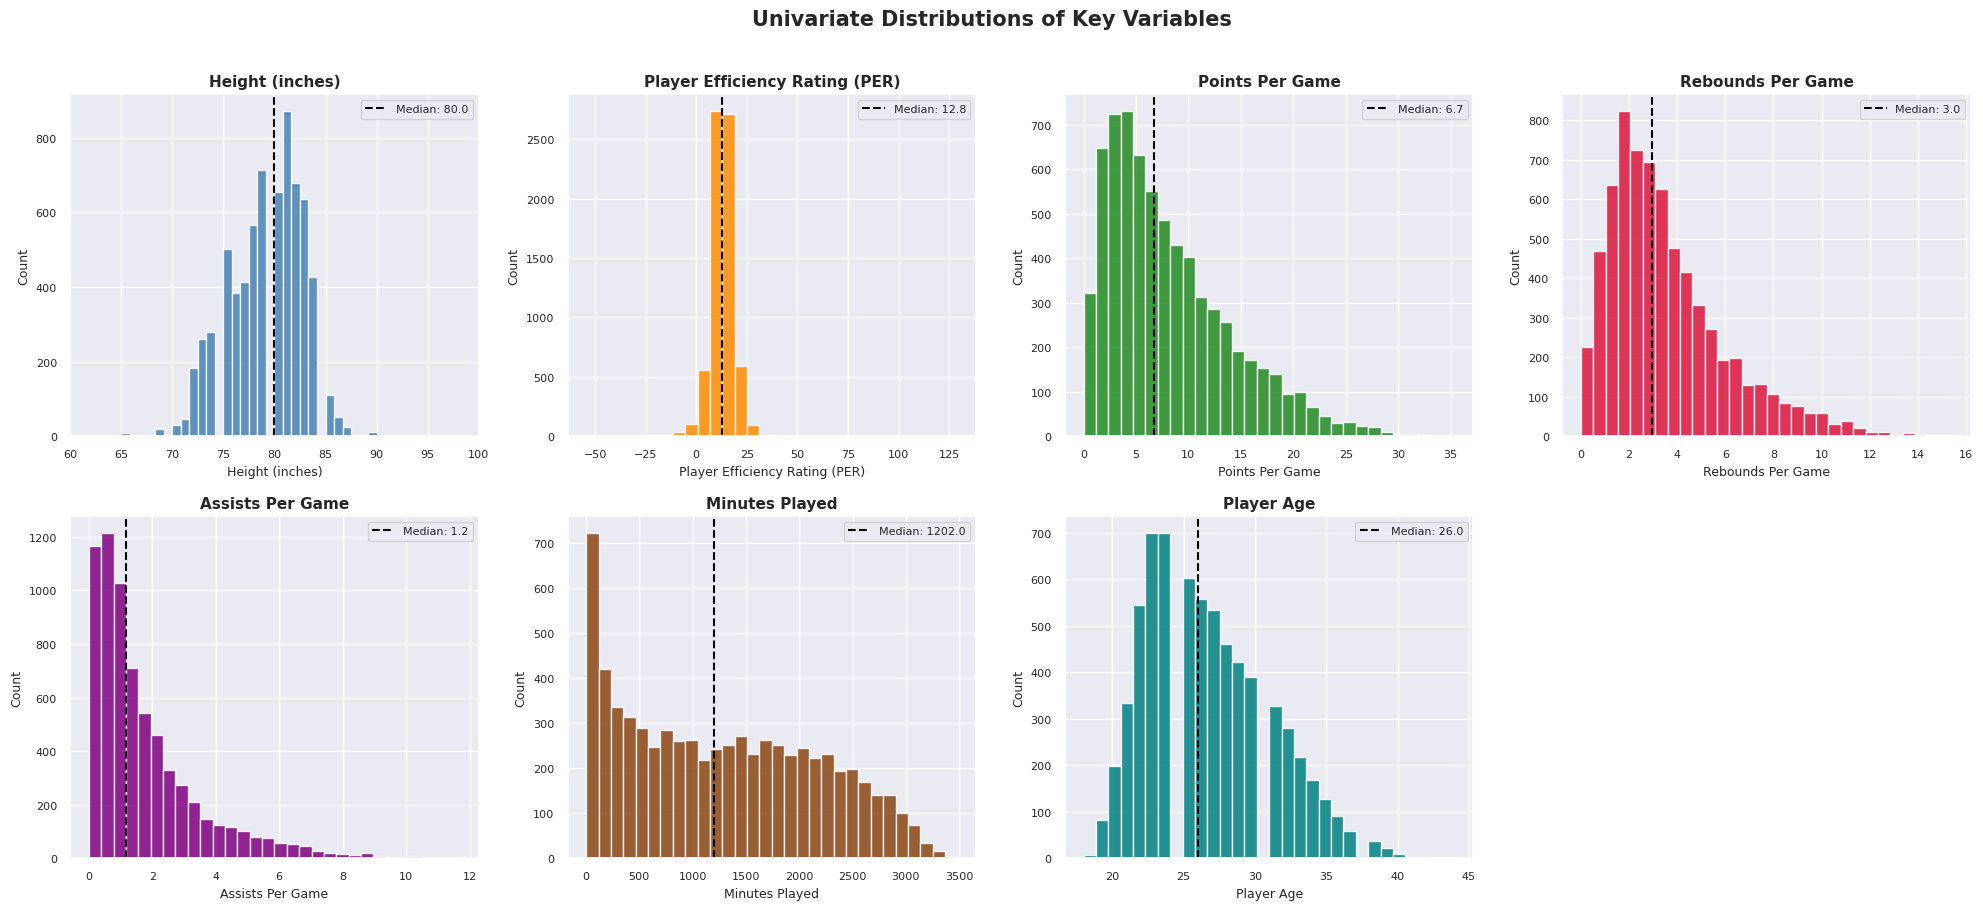

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Univariate Distributions of Key Variables',
             fontsize=15, fontweight='bold', y=1.01)

vars_to_plot = [
    (col_height, 'Height (inches)',               'steelblue'),
    (col_per,    'Player Efficiency Rating (PER)', 'darkorange'),
    (col_pts,    'Points Per Game',                'forestgreen'),
    (col_trb,    'Rebounds Per Game',              'crimson'),
    (col_ast,    'Assists Per Game',               'purple'),
    (col_mp,     'Minutes Played',                 'saddlebrown'),
    (col_age,    'Player Age',                     'teal'),
]

for ax, (col, label, color) in zip(axes.flatten(), vars_to_plot):
    if col is None or col not in df_eda.columns:
        ax.set_visible(False)
        continue
    data = df_eda[col].dropna()
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    med = data.median()
    ax.axvline(med, color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {med:.1f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    if col == col_height:
        ax.set_xlim(60, 100)   # enforce inches range on x-axis

axes[1, 3].set_visible(False)
plt.tight_layout()
plt.savefig('results/eda_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

The univariate distributions show that height is approximately bell-shaped, while PER is concentrated around modest positive values with several outliers on both ends. Points, rebounds, and assists per game are right-skewed, indicating that most player-seasons involve relatively modest production while a smaller number of high-usage players produce at much higher levels. Minutes played is also right-skewed, reflecting the difference between low-minute bench roles and heavier-minute rotation players. Age is closer to a unimodal distribution centered in the mid-20s, which is consistent with the typical NBA career window.

### Section 2: Bivariate Relationships Between Height and Performance Outcomes

We now examine how height relates to each key outcome variable — including PER, points, rebounds, assists, and field goals made per game. We use scatter plots with OLS regression lines overlaid, and report both the **Pearson correlation coefficient (r)**, which measures strength and direction of the linear relationship, and the **regression slope**, which describes how many units the outcome changes per additional inch of height. These are distinct quantities: r measures association strength (–1 to 1), while slope is in outcome units per inch.

Minutes played is overlaid as color to visualize its potential confounding role.

Player Efficiency Rating (PER): Pearson r = 0.055, slope = 0.0931
Points Per Game: Pearson r = -0.083, slope = -0.1364
Rebounds Per Game: Pearson r = 0.418, slope = 0.2866
Assists Per Game: Pearson r = -0.481, slope = -0.2388
Field Goals Made Per Game: Pearson r = -0.047, slope = -0.0281


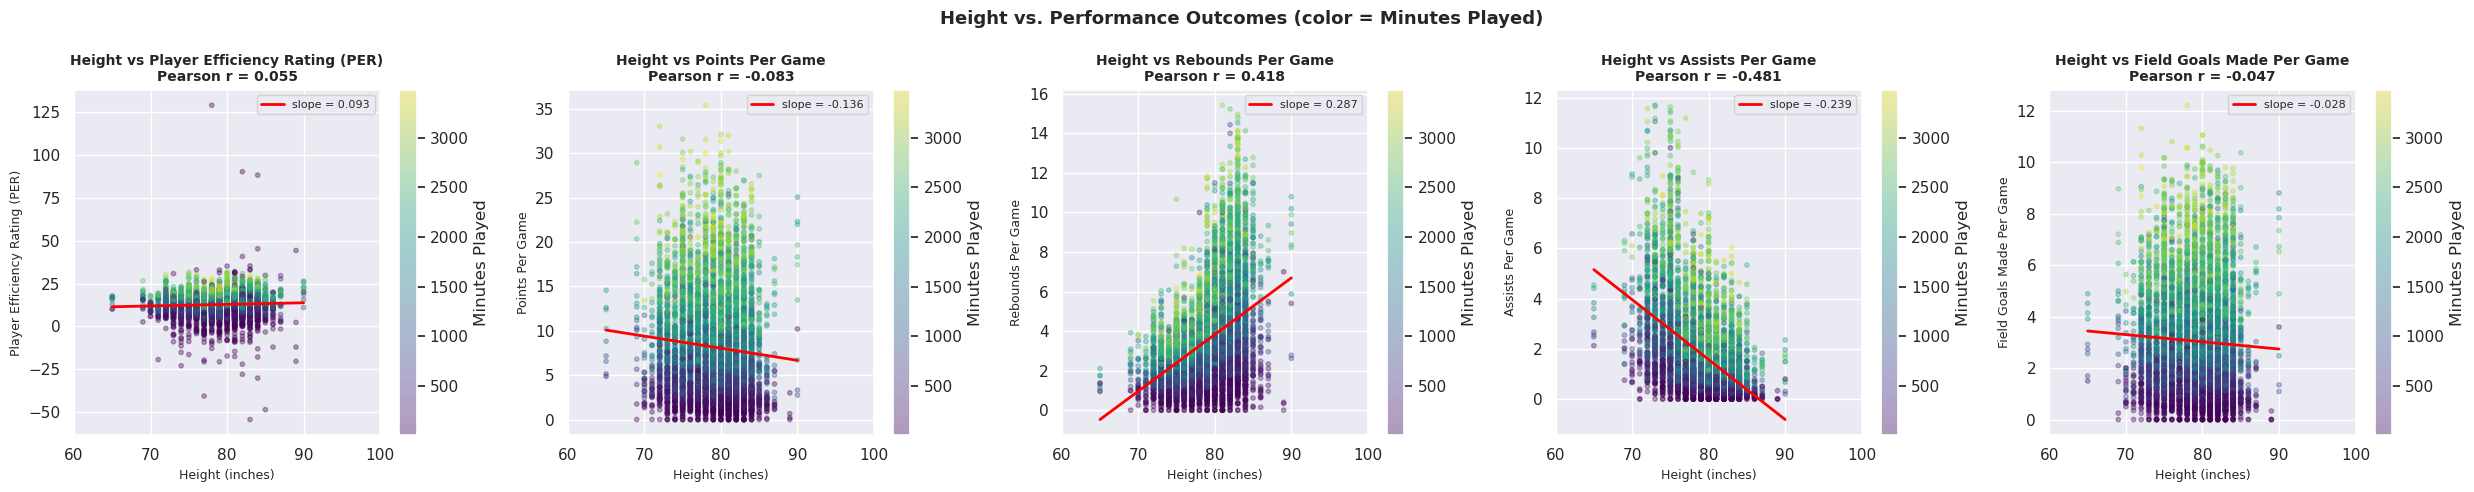

In [4]:
outcomes = [
    (col_per,  'Player Efficiency Rating (PER)'),
    (col_pts,  'Points Per Game'),
    (col_trb,  'Rebounds Per Game'),
    (col_ast,  'Assists Per Game'),
    (col_fg,   'Field Goals Made Per Game'),
]
outcomes = [(c, l) for c, l in outcomes if c and c in df_eda.columns]

fig, axes = plt.subplots(1, len(outcomes), figsize=(5*len(outcomes), 5))
fig.suptitle('Height vs. Performance Outcomes (color = Minutes Played)',
             fontsize=13, fontweight='bold')
if len(outcomes) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, outcomes):
    sub = df_eda[[col_height, col, col_mp]].dropna()
    sc  = ax.scatter(sub[col_height], sub[col],
                     c=sub[col_mp], cmap='viridis', alpha=0.35, s=10)
    m, b = np.polyfit(sub[col_height], sub[col], 1)
    x_line = np.linspace(sub[col_height].min(), sub[col_height].max(), 100)
    ax.plot(x_line, m*x_line + b, color='red', linewidth=2,
            label=f'slope = {m:.3f}')
    r = sub[col_height].corr(sub[col])
    ax.set_title(f'Height vs {label}\nPearson r = {r:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Height (inches)', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlim(60, 100)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='Minutes Played')
    print(f"{label}: Pearson r = {r:.3f}, slope = {m:.4f}")

plt.tight_layout()
plt.savefig('results/eda_height_vs_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

At the pooled level, height shows only a weak relationship with PER, suggesting that height alone explains little variation in overall player efficiency. By contrast, height is much more clearly associated with rebounds per game, which is consistent with the basketball logic that rebounding is more strongly tied to size and interior role. Height shows a weak or near-zero relationship with points per game overall, indicating that scoring is distributed across multiple player types and roles. Height is clearly negatively associated with assists per game, reflecting that playmaking responsibilities are concentrated among guards rather than taller frontcourt players.

Together, these pooled patterns suggest that height is not a universal predictor of performance. Instead, its association with production depends on which outcome is being considered, motivating the position-stratified and interaction-based analyses that follow.

### Section 3: Position-Stratified Analysis of Height and Performance

Our position-stratified analysis examines whether the relationship between height and PER differs across guards, forwards, and centers. Rather than assuming a single pooled effect of height for all players, this section explores whether the direction and strength of the height–performance relationship varies by positional role.

/tmp/ipykernel_2977/3850607833.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='pos_group', y=col_height,
/tmp/ipykernel_2977/3850607833.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='pos_group', y=col_per,


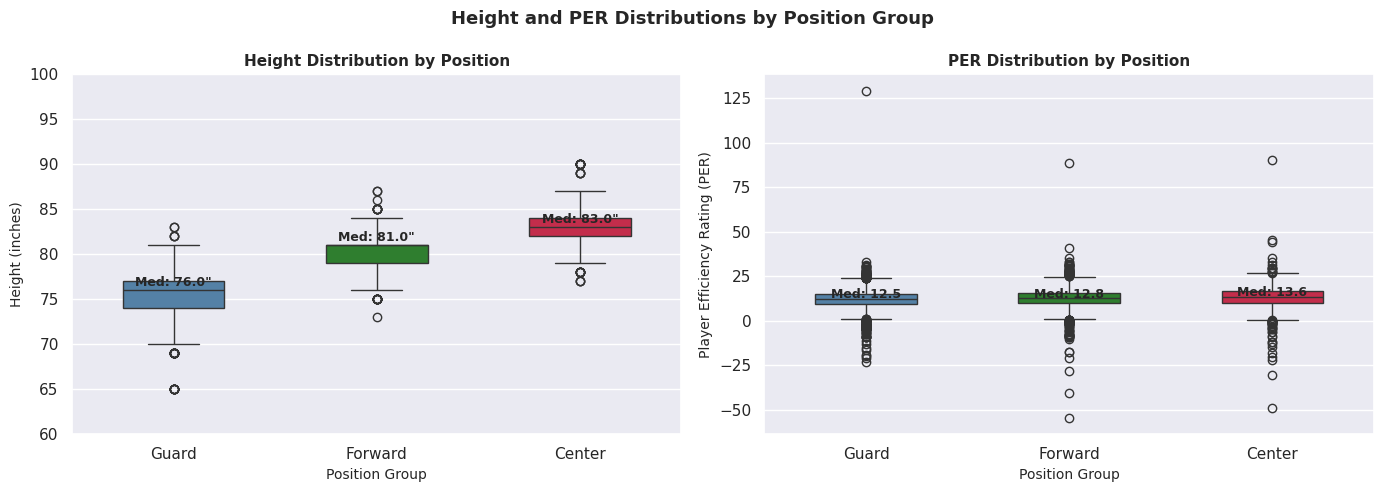

Median height and PER by position:
           height_in   PER
pos_group                 
Center          83.0  13.6
Forward         81.0  12.8
Guard           76.0  12.5


In [5]:
pos_order = ['Guard', 'Forward', 'Center']
palette   = {'Guard': 'steelblue', 'Forward': 'forestgreen', 'Center': 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Height and PER Distributions by Position Group',
             fontsize=13, fontweight='bold')

# Box plot 1: Height by position
sns.boxplot(data=df_eda, x='pos_group', y=col_height,
            order=pos_order, palette=palette, ax=axes[0], width=0.5)
axes[0].set_title('Height Distribution by Position', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Position Group', fontsize=10)
axes[0].set_ylabel('Height (inches)', fontsize=10)
axes[0].set_ylim(60, 100)   # enforce inches range

for i, pos in enumerate(pos_order):
    med = df_eda[df_eda['pos_group'] == pos][col_height].median()
    axes[0].text(i, med + 0.5, f'Med: {med:.1f}"',
                 ha='center', fontsize=9, fontweight='bold')

# Box plot 2: PER by position
sns.boxplot(data=df_eda, x='pos_group', y=col_per,
            order=pos_order, palette=palette, ax=axes[1], width=0.5)
axes[1].set_title('PER Distribution by Position', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Position Group', fontsize=10)
axes[1].set_ylabel('Player Efficiency Rating (PER)', fontsize=10)

for i, pos in enumerate(pos_order):
    med = df_eda[df_eda['pos_group'] == pos][col_per].median()
    axes[1].text(i, med + 0.3, f'Med: {med:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results/eda_height_PER_by_position_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print("Median height and PER by position:")
print(df_eda.groupby('pos_group')[[col_height, col_per]].median().round(2))

Guard: Pearson r = -0.066, slope = -0.1594, n = 2705
Forward: Pearson r = 0.140, slope = 0.5099, n = 2704
Center: Pearson r = 0.023, slope = 0.0943, n = 1467


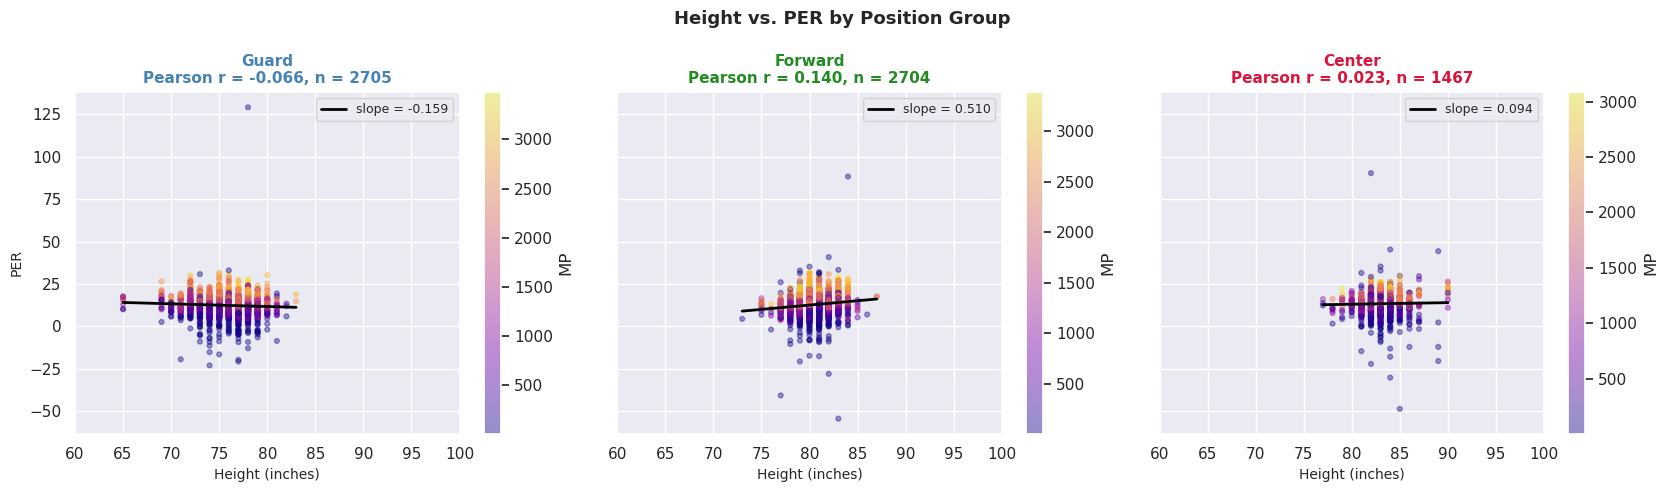

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
fig.suptitle('Height vs. PER by Position Group', fontsize=13, fontweight='bold')

for ax, pos in zip(axes, pos_order):
    sub_pos = df_eda[df_eda['pos_group'] == pos][[col_height, col_per, col_mp]].dropna()
    sc = ax.scatter(sub_pos[col_height], sub_pos[col_per],
                    c=sub_pos[col_mp], cmap='plasma', alpha=0.4, s=12)
    m, b = np.polyfit(sub_pos[col_height], sub_pos[col_per], 1)
    x_line = np.linspace(sub_pos[col_height].min(), sub_pos[col_height].max(), 100)
    ax.plot(x_line, m*x_line + b, color='black', linewidth=2,
            label=f'slope = {m:.3f}')
    r   = sub_pos[col_height].corr(sub_pos[col_per])
    n   = len(sub_pos)
    ax.set_title(f'{pos}\nPearson r = {r:.3f}, n = {n}',
                 fontsize=11, fontweight='bold', color=palette[pos])
    ax.set_xlabel('Height (inches)', fontsize=10)
    ax.set_ylabel('PER' if pos == 'Guard' else '', fontsize=10)
    ax.set_xlim(60, 100)
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label='MP')
    print(f"{pos}: Pearson r = {r:.3f}, slope = {m:.4f}, n = {n}")

plt.tight_layout()
plt.savefig('results/eda_height_PER_stratified.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Full summary statistics by position
summary_cols = [c for c in [col_height, col_per, col_pts, col_trb, col_ast, col_fg]
                if c and c in df_eda.columns]
summary = (df_eda.groupby('pos_group')[summary_cols]
           .agg(['median', 'mean', 'std'])
           .round(2))
print("Summary statistics by position group:")
print(summary.to_string())

# Pearson correlations of height with each outcome, by position
print("\nPearson r of Height with each outcome, by position:")
for pos in pos_order:
    sub_pos = df_eda[df_eda['pos_group'] == pos][summary_cols].dropna()
    corrs = sub_pos.corr()[col_height].drop(col_height).round(3)
    print(f"\n  {pos} (n={len(sub_pos)}):")
    for col_name, r_val in corrs.items():
        print(f"    {col_name}: r = {r_val}")

Summary statistics by position group:
          height_in                 PER              PTS_pg             TRB_pg             AST_pg              FG_pg            
             median   mean   std median   mean   std median  mean   std median  mean   std median  mean   std median  mean   std
pos_group                                                                                                                       
Center         83.0  83.10  1.62   13.6  13.33  6.59   5.19  6.62  5.19   4.25  4.90  3.02   0.57  0.84  0.82   2.07  2.62  2.02
Forward        81.0  80.46  1.61   12.8  12.80  5.87   6.75  8.24  5.95   3.60  4.04  2.46   0.96  1.29  1.14   2.55  3.11  2.20
Guard          76.0  75.58  2.43   12.5  12.41  5.85   7.62  8.90  6.06   2.18  2.37  1.34   2.18  2.79  2.16   2.80  3.22  2.14

Pearson r of Height with each outcome, by position:

  Guard (n=2705):
    PER: r = -0.066
    PTS_pg: r = 0.029
    TRB_pg: r = 0.205
    AST_pg: r = -0.276
    FG_pg: r = 0.029

  Forwa

**Interpretation:**

Height distributions by position confirm the expected physical ordering of NBA roles: guards are shortest on average, forwards are intermediate, and centers are tallest. PER distributions, however, overlap substantially across groups, suggesting that players in different roles can still achieve comparable levels of efficiency.

The more important result comes from the within-position relationship between height and PER. Rather than showing one consistent pattern across all groups, the data suggest that height matters differently by role. Among guards, the relationship is weakly negative; among forwards, it is positive and more pronounced; and among centers, it is close to zero. These exploratory patterns anticipate the regression and ANOVA results that follow, and they support the broader idea that the value of height is position-dependent rather than uniform across all NBA players.

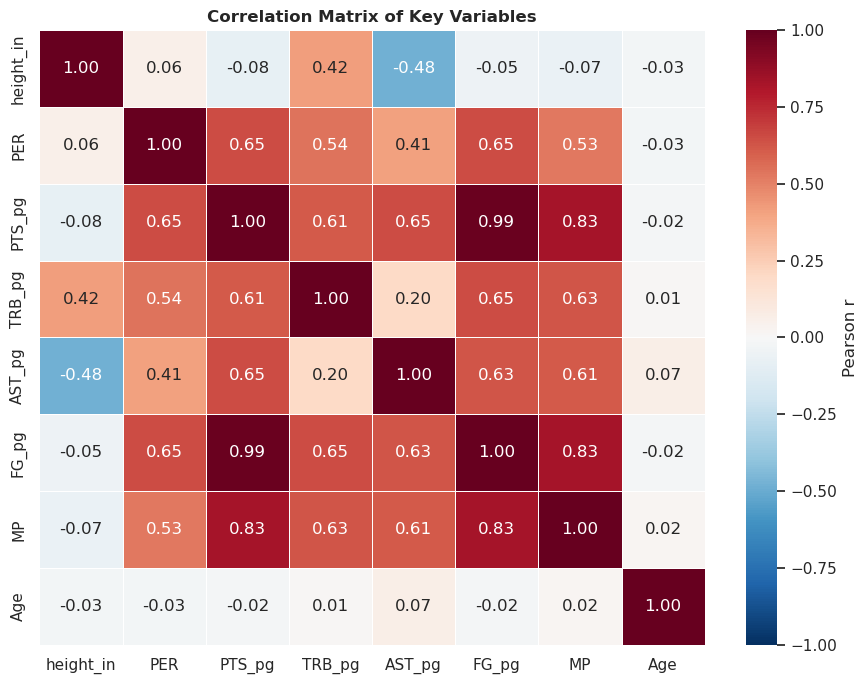

Key correlations with height:
TRB_pg    0.42
PER       0.06
Age      -0.03
FG_pg    -0.05
MP       -0.07
PTS_pg   -0.08
AST_pg   -0.48

MP–PTS correlation: 0.83
MP–TRB correlation: 0.63


In [8]:
numeric_cols = [c for c in [col_height, col_per, col_pts, col_trb,
                              col_ast, col_fg, col_mp, col_age]
                if c and c in df_eda.columns]
corr_matrix = df_eda[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix of Key Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key correlations explicitly
print("Key correlations with height:")
height_corrs = corr_matrix[col_height].drop(col_height).sort_values(ascending=False)
print(height_corrs.to_string())
print("\nMP–PTS correlation:", corr_matrix.loc[col_mp, col_pts] if col_mp in corr_matrix.index and col_pts in corr_matrix.columns else "N/A")
print("MP–TRB correlation:", corr_matrix.loc[col_mp, col_trb] if col_mp in corr_matrix.index and col_trb in corr_matrix.columns else "N/A")

**Correlation Heatmap Interpretation:**

- **Height–TRB/G** shows the strongest positive correlation among the height-related outcome pairs, confirming that height is most directly linked to rebounding — a physically size-dependent skill.
- **Height–AST/G** is clearly negative, which is consistent with the fact that assists are concentrated among guards rather than taller frontcourt players.
- **Height–PTS/G** and **Height–FG/G** are both near zero overall, suggesting that scoring volume is not straightforwardly height-dependent in pooled NBA data.
- **MP** remains positively correlated with several production variables, reinforcing that playing opportunity is an important control variable in later models.

Overall, the heatmap supports the same conclusion as the earlier bivariate plots: height is not strongly related to PER in pooled data, but it is more strongly associated with role-specific outcomes such as rebounds and assists. These patterns justify both our use of control variables and our decision to test position-dependent relationships in the regression analyses.

### Analysis 1: Multiple Linear Regression — Height Predicting PER with Controls

To formally test whether height is associated with PER after accounting for potential confounders, we estimate a series of OLS regression models. The first model examines the pooled association between height and PER alone. The second model adds controls for position group, minutes played, age, weight, and season. The third model introduces a Height × Position interaction to test whether the height–PER relationship differs across Guards, Forwards, and Centers. In these models, Center is treated as the reference group.

Regression sample shape: (6876, 7)
   height_in   PER      MP   Age  weight    Year pos_group
0       72.0  13.1   608.0  23.0   161.0  2008.0     Guard
1       72.0  12.9  1998.0  24.0   161.0  2009.0     Guard
2       72.0  16.0  2919.0  25.0   161.0  2010.0     Guard
3       72.0  13.1  1284.0  26.0   161.0  2011.0     Guard
4       72.0  11.8   997.0  28.0   161.0  2013.0     Guard
MODEL 1: Height only
Height coef = 0.0931
p-value     = 0.0000
R²          = 0.0031

MODEL 2: Height + Position + Controls + Year FE
                           coef  std_err  p_value
height_in               -0.0754   0.0381   0.0477
C(pos_group)[T.Forward] -1.0742   0.2056   0.0000
C(pos_group)[T.Guard]   -1.4055   0.3350   0.0000
MP                       0.0036   0.0001   0.0000
Age                     -0.0526   0.0140   0.0002
weight                   0.0192   0.0046   0.0000
R² = 0.2988 | Adj R² = 0.2968

MODEL 3: Height × Position Interaction + Controls + Year FE
                                     

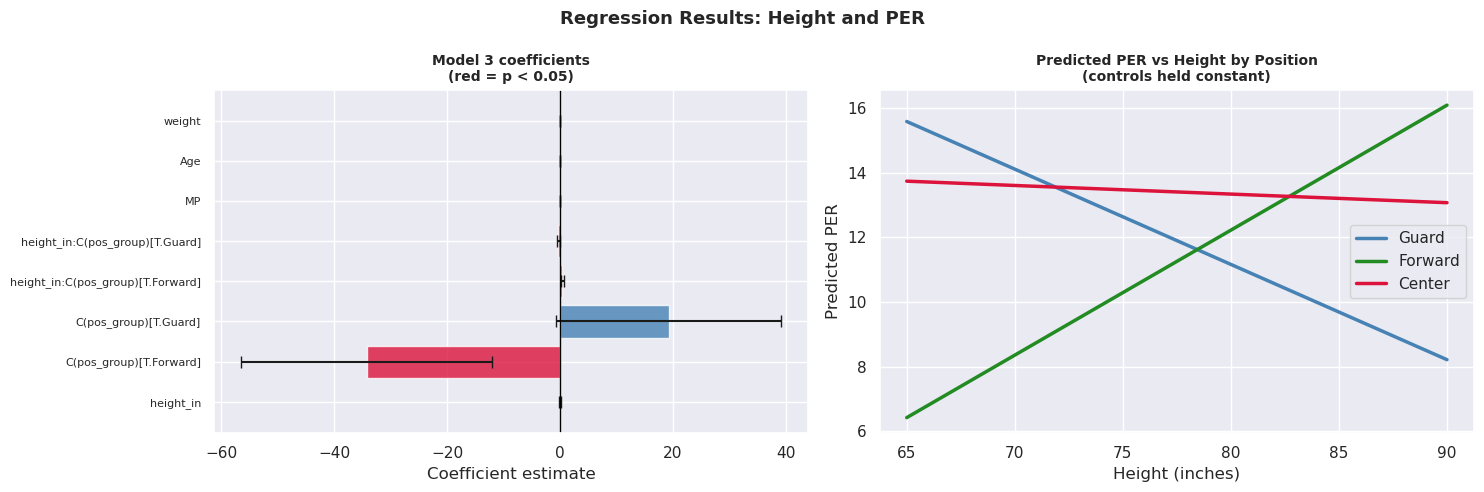

In [9]:
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# 1) Prepare regression dataset
reg_cols = [col_height, col_per, col_mp, col_age, col_wt, col_year, "pos_group"]
df_reg = df_eda[reg_cols].dropna().copy()

# Make reference group explicit: Center = baseline
df_reg["pos_group"] = pd.Categorical(
    df_reg["pos_group"],
    categories=["Center", "Forward", "Guard"]
)

print("Regression sample shape:", df_reg.shape)
print(df_reg.head())

# 2) Fit models
formula1 = f"{col_per} ~ {col_height}"
formula2 = f"{col_per} ~ {col_height} + C(pos_group) + {col_mp} + {col_age} + {col_wt} + C({col_year})"
formula3 = f"{col_per} ~ {col_height} * C(pos_group) + {col_mp} + {col_age} + {col_wt} + C({col_year})"

model1 = smf.ols(formula1, data=df_reg).fit(cov_type="HC3")
model2 = smf.ols(formula2, data=df_reg).fit(cov_type="HC3")
model3 = smf.ols(formula3, data=df_reg).fit(cov_type="HC3")


# 3) Print compact summaries
print("=" * 70)
print("MODEL 1: Height only")
print(f"Height coef = {model1.params[col_height]:.4f}")
print(f"p-value     = {model1.pvalues[col_height]:.4f}")
print(f"R²          = {model1.rsquared:.4f}")

print("\n" + "=" * 70)
print("MODEL 2: Height + Position + Controls + Year FE")
key_terms_m2 = [t for t in [
    col_height,
    "C(pos_group)[T.Forward]",
    "C(pos_group)[T.Guard]",
    col_mp,
    col_age,
    col_wt
] if t in model2.params.index]

m2_table = pd.DataFrame({
    "coef": model2.params[key_terms_m2],
    "std_err": model2.bse[key_terms_m2],
    "p_value": model2.pvalues[key_terms_m2]
}).round(4)
print(m2_table)
print(f"R² = {model2.rsquared:.4f} | Adj R² = {model2.rsquared_adj:.4f}")

print("\n" + "=" * 70)
print("MODEL 3: Height × Position Interaction + Controls + Year FE")
key_terms_m3 = [t for t in [
    col_height,
    "C(pos_group)[T.Forward]",
    "C(pos_group)[T.Guard]",
    f"{col_height}:C(pos_group)[T.Forward]",
    f"{col_height}:C(pos_group)[T.Guard]",
    col_mp,
    col_age,
    col_wt
] if t in model3.params.index]

m3_table = pd.DataFrame({
    "coef": model3.params[key_terms_m3],
    "std_err": model3.bse[key_terms_m3],
    "p_value": model3.pvalues[key_terms_m3]
}).round(4)
print(m3_table)
print(f"R² = {model3.rsquared:.4f} | Adj R² = {model3.rsquared_adj:.4f}")


# 4) Calculate implied slopes by position
center_slope = model3.params[col_height]
forward_slope = center_slope + model3.params.get(f"{col_height}:C(pos_group)[T.Forward]", 0)
guard_slope = center_slope + model3.params.get(f"{col_height}:C(pos_group)[T.Guard]", 0)

print("\nImplied height slopes from Model 3:")
print(f"  Center  slope = {center_slope:.4f}")
print(f"  Forward slope = {forward_slope:.4f}")
print(f"  Guard   slope = {guard_slope:.4f}")


# 5) Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Regression Results: Height and PER", fontsize=13, fontweight="bold")

# Left panel: selected coefficients from Model 3
coef_plot_terms = key_terms_m3
coef_vals = model3.params[coef_plot_terms]
coef_ci = model3.conf_int().loc[coef_plot_terms]

ypos = np.arange(len(coef_plot_terms))
colors = ["crimson" if model3.pvalues[t] < 0.05 else "steelblue" for t in coef_plot_terms]

axes[0].barh(
    ypos,
    coef_vals,
    xerr=[coef_vals - coef_ci[0], coef_ci[1] - coef_vals],
    color=colors,
    alpha=0.8,
    capsize=4
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(coef_plot_terms, fontsize=8)
axes[0].set_xlabel("Coefficient estimate")
axes[0].set_title("Model 3 coefficients\n(red = p < 0.05)", fontsize=10, fontweight="bold")

# Right panel: predicted PER by height and position
h_range = np.linspace(df_reg[col_height].min(), df_reg[col_height].max(), 100)
year_ref = int(df_reg[col_year].median())
mp_ref = df_reg[col_mp].median()
age_ref = df_reg[col_age].median()
wt_ref = df_reg[col_wt].median()

pos_colors = {"Guard": "steelblue", "Forward": "forestgreen", "Center": "crimson"}

for pos in ["Guard", "Forward", "Center"]:
    pred_df = pd.DataFrame({
        col_height: h_range,
        "pos_group": pd.Categorical([pos] * len(h_range), categories=["Center", "Forward", "Guard"]),
        col_mp: mp_ref,
        col_age: age_ref,
        col_wt: wt_ref,
        col_year: year_ref
    })
    preds = model3.predict(pred_df)
    axes[1].plot(h_range, preds, color=pos_colors[pos], linewidth=2.5, label=pos)

axes[1].set_xlabel("Height (inches)")
axes[1].set_ylabel("Predicted PER")
axes[1].set_title("Predicted PER vs Height by Position\n(controls held constant)", fontsize=10, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/regression_height_per.png", dpi=150, bbox_inches="tight")
plt.show()

This figure summarizes the regression results for PER. The coefficient plot highlights which terms in the interaction model are statistically significant, while the predicted-lines panel shows that the relationship between height and PER differs across position groups once the control variables are held constant.

**Analysis 1 Interpretation**

**Model 1** shows that height alone is a statistically significant predictor of PER, but the effect is extremely small in practical terms. The estimated coefficient is positive (β = 0.093, p < 0.001), yet the model explains very little of the total variation in PER (R² = 0.003). This suggests that a simple pooled relationship between height and efficiency exists, but it is weak and not especially informative on its own.

**Model 2** adds controls for position group, minutes played, age, weight, and season. After these controls are included, the coefficient for height becomes slightly negative (β = -0.075, p = 0.048). This indicates that the weak positive pooled relationship in Model 1 is not robust once important confounders are taken into account. In particular, playing time, age, body size, and positional role explain substantially more variation in PER than height alone.

**Model 3** directly tests our main hypothesis by allowing the effect of height to vary across position groups. With Center as the reference group, the baseline height effect is close to zero and not statistically significant for centers (β = -0.027, p = 0.816). However, the interaction term for forwards is positive and significant (β = 0.414, p = 0.003), while the interaction term for guards is negative and significant (β = -0.268, p = 0.030). The implied slopes show that height is negatively associated with PER among guards, positively associated with PER among forwards, and near zero among centers. Taken together, these results support the conclusion that the relationship between height and player efficiency is position-dependent rather than uniform across all NBA players.

### Analysis 2: Position-Group Comparison — One-Way ANOVA and Post-Hoc Tests

To compare average PER across position groups, we conduct a one-way ANOVA followed by Tukey HSD post-hoc tests. We then examine the height–PER relationship within each position group using Pearson correlation coefficients. Together, these tests allow us to distinguish between two different questions: whether average efficiency differs by position, and whether the association between height and efficiency changes across positions.

One-way ANOVA — PER across positions
F = 11.3416
p = 0.0000
Result: Significant

Group means / medians:
Guard    | mean = 12.406 | median = 12.500 | n = 2705
Forward  | mean = 12.797 | median = 12.800 | n = 2704
Center   | mean = 13.332 | median = 13.600 | n = 1467

Tukey HSD post-hoc results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
 Center Forward  -0.5347  0.017 -0.9925 -0.0769   True
 Center   Guard   -0.926    0.0 -1.3838 -0.4682   True
Forward   Guard  -0.3913 0.0446 -0.7752 -0.0074   True
------------------------------------------------------

Height–PER Pearson correlations by position:
Guard    | r = -0.0661 | p = 0.0006 | n = 2705
Forward  | r = 0.1400 | p = 0.0000 | n = 2704
Center   | r = 0.0232 | p = 0.3746 | n = 1467


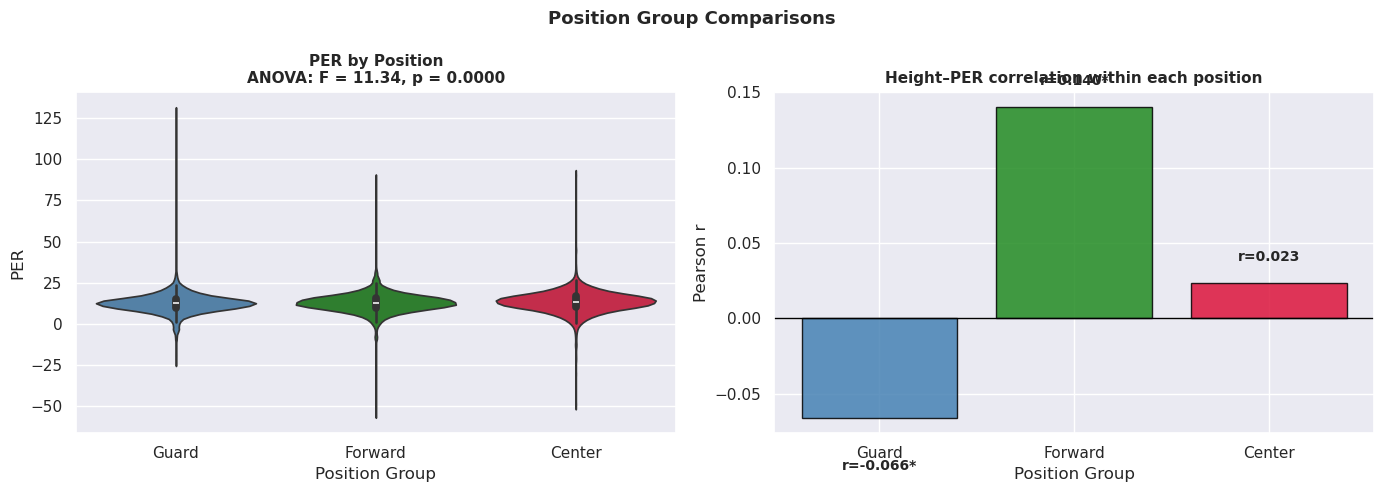

In [10]:
from scipy.stats import f_oneway, pearsonr
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# 1) One-way ANOVA: PER across positions
anova_positions = ["Guard", "Forward", "Center"]

groups = [
    df_eda.loc[df_eda["pos_group"] == pos, col_per].dropna().values
    for pos in anova_positions
]

f_stat, p_anova = f_oneway(*groups)

print("One-way ANOVA — PER across positions")
print(f"F = {f_stat:.4f}")
print(f"p = {p_anova:.4f}")
print("Result:", "Significant" if p_anova < 0.05 else "Not significant")

print("\nGroup means / medians:")
for pos in anova_positions:
    vals = df_eda.loc[df_eda["pos_group"] == pos, col_per].dropna()
    print(f"{pos:8s} | mean = {vals.mean():.3f} | median = {vals.median():.3f} | n = {len(vals)}")


# 2) Tukey HSD post-hoc
df_tukey = df_eda[df_eda["pos_group"].isin(anova_positions)][[col_per, "pos_group"]].dropna()
tukey = pairwise_tukeyhsd(endog=df_tukey[col_per], groups=df_tukey["pos_group"], alpha=0.05)

print("\nTukey HSD post-hoc results:")
print(tukey.summary())


# 3) Height–PER correlations within each position
corr_rows = []
print("\nHeight–PER Pearson correlations by position:")
for pos in anova_positions:
    sub = df_eda.loc[df_eda["pos_group"] == pos, [col_height, col_per]].dropna()
    r, p = pearsonr(sub[col_height], sub[col_per])
    corr_rows.append({"Position": pos, "r": r, "p": p, "n": len(sub)})
    print(f"{pos:8s} | r = {r:.4f} | p = {p:.4f} | n = {len(sub)}")

corr_df = pd.DataFrame(corr_rows)


# 4) Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Position Group Comparisons", fontsize=13, fontweight="bold")

palette_pos = {"Guard": "steelblue", "Forward": "forestgreen", "Center": "crimson"}

# Left: PER distribution by position
sns.violinplot(
    data=df_eda[df_eda["pos_group"].isin(anova_positions)],
    x="pos_group",
    y=col_per,
    order=anova_positions,
    palette=palette_pos,
    inner="box",
    ax=axes[0]
)
axes[0].set_title(f"PER by Position\nANOVA: F = {f_stat:.2f}, p = {p_anova:.4f}", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Position Group")
axes[0].set_ylabel("PER")

# Right: correlation by position
bars = axes[1].bar(
    corr_df["Position"],
    corr_df["r"],
    color=[palette_pos[p] for p in corr_df["Position"]],
    edgecolor="black",
    alpha=0.85
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Height–PER correlation within each position", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Position Group")
axes[1].set_ylabel("Pearson r")

for i, row in corr_df.iterrows():
    label = f"r={row['r']:.3f}"
    if row["p"] < 0.05:
        label += "*"
    y = row["r"] + 0.015 if row["r"] >= 0 else row["r"] - 0.035
    axes[1].text(i, y, label, ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("results/anova_position_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

This figure compares PER across position groups and summarizes the height–PER correlation within each group. The left panel shows that average PER differs significantly by position, while the right panel shows that the direction and strength of the height–PER relationship also vary across guards, forwards, and centers.

**Analysis 2 Interpretation**

The one-way ANOVA shows that mean PER differs significantly across position groups (F = 11.34, p < 0.001). Average PER is highest among centers (mean = 13.33), followed by forwards (mean = 12.80), and lowest among guards (mean = 12.41). Tukey HSD post-hoc tests indicate that all three pairwise differences are statistically significant, meaning that centers, forwards, and guards each differ from one another in average PER.

However, the within-position height–PER correlations reveal a more nuanced pattern. Among guards, height is weakly but significantly negatively associated with PER (r = -0.066, p < 0.001). Among forwards, height is positively associated with PER (r = 0.140, p < 0.001), and this is the strongest within-group relationship observed here. Among centers, the correlation between height and PER is close to zero and not statistically significant (r = 0.023, p = 0.375).

Taken together, these results show that positional groups differ not only in their average efficiency levels, but also in how height relates to efficiency within each role. This complements the interaction regression from Analysis 1: height appears least beneficial for guards, most beneficial for forwards, and largely unrelated to PER among centers in this sample.

### Robustness Check: Height Predicting Rebounds Per Game

Because our exploratory analysis suggests that height is most strongly related to rebounding, we run an additional interaction model using rebounds per game as the outcome. This checks whether the position-dependent role of height remains visible for a more size-dependent basketball statistic.

Robustness model: Rebounds per game
                                      coef  std_err  p_value
height_in                           0.0158   0.0285   0.5787
C(pos_group)[T.Forward]           -19.6146   2.7538   0.0000
C(pos_group)[T.Guard]              -1.9194   2.4487   0.4331
height_in:C(pos_group)[T.Forward]   0.2340   0.0335   0.0000
height_in:C(pos_group)[T.Guard]     0.0001   0.0297   0.9969
MP                                  0.0018   0.0000   0.0000
Age                                 0.0007   0.0039   0.8668
weight                              0.0175   0.0013   0.0000
R² = 0.6615 | Adj R² = 0.6605


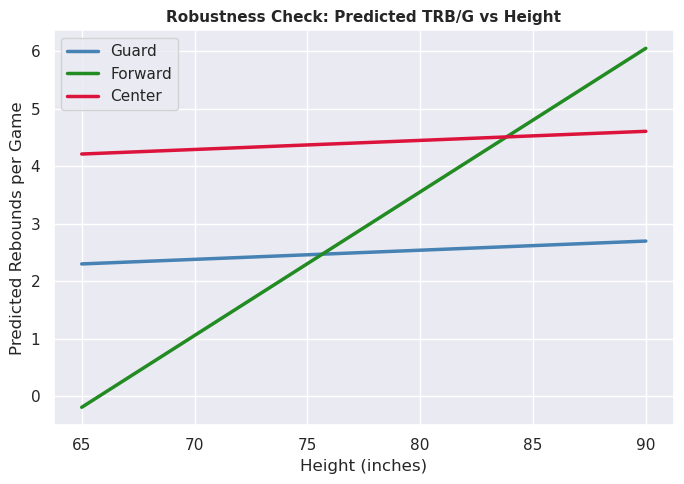


Implied height slopes from robustness model:
  Center  slope = 0.0158
  Forward slope = 0.2498
  Guard   slope = 0.0159


In [11]:
# Robustness check: TRB/G as outcome
rob_cols = [col_height, col_trb, col_mp, col_age, col_wt, col_year, "pos_group"]
df_rob = df_eda[rob_cols].dropna().copy()

df_rob["pos_group"] = pd.Categorical(
    df_rob["pos_group"],
    categories=["Center", "Forward", "Guard"]
)

formula_rob = f"{col_trb} ~ {col_height} * C(pos_group) + {col_mp} + {col_age} + {col_wt} + C({col_year})"
rob_model = smf.ols(formula_rob, data=df_rob).fit(cov_type="HC3")

print("Robustness model: Rebounds per game")
rob_terms = [t for t in [
    col_height,
    "C(pos_group)[T.Forward]",
    "C(pos_group)[T.Guard]",
    f"{col_height}:C(pos_group)[T.Forward]",
    f"{col_height}:C(pos_group)[T.Guard]",
    col_mp,
    col_age,
    col_wt
] if t in rob_model.params.index]

rob_table = pd.DataFrame({
    "coef": rob_model.params[rob_terms],
    "std_err": rob_model.bse[rob_terms],
    "p_value": rob_model.pvalues[rob_terms]
}).round(4)

print(rob_table)
print(f"R² = {rob_model.rsquared:.4f} | Adj R² = {rob_model.rsquared_adj:.4f}")

# Plot predicted TRB/G by height and position
fig, ax = plt.subplots(figsize=(7, 5))
h_range = np.linspace(df_rob[col_height].min(), df_rob[col_height].max(), 100)
year_ref = int(df_rob[col_year].median())
mp_ref = df_rob[col_mp].median()
age_ref = df_rob[col_age].median()
wt_ref = df_rob[col_wt].median()

pos_colors = {"Guard": "steelblue", "Forward": "forestgreen", "Center": "crimson"}

for pos in ["Guard", "Forward", "Center"]:
    pred_df = pd.DataFrame({
        col_height: h_range,
        "pos_group": pd.Categorical([pos] * len(h_range), categories=["Center", "Forward", "Guard"]),
        col_mp: mp_ref,
        col_age: age_ref,
        col_wt: wt_ref,
        col_year: year_ref
    })
    preds = rob_model.predict(pred_df)
    ax.plot(h_range, preds, color=pos_colors[pos], linewidth=2.5, label=pos)

ax.set_title("Robustness Check: Predicted TRB/G vs Height", fontsize=11, fontweight="bold")
ax.set_xlabel("Height (inches)")
ax.set_ylabel("Predicted Rebounds per Game")
ax.legend()

plt.tight_layout()
plt.savefig("results/robustness_trb_height.png", dpi=150, bbox_inches="tight")
plt.show()

center_slope_rob = rob_model.params[col_height]
forward_slope_rob = center_slope_rob + rob_model.params.get(f"{col_height}:C(pos_group)[T.Forward]", 0)
guard_slope_rob = center_slope_rob + rob_model.params.get(f"{col_height}:C(pos_group)[T.Guard]", 0)

print("\nImplied height slopes from robustness model:")
print(f"  Center  slope = {center_slope_rob:.4f}")
print(f"  Forward slope = {forward_slope_rob:.4f}")
print(f"  Guard   slope = {guard_slope_rob:.4f}")

This figure presents a robustness check using rebounds per game as the outcome. Because rebounding is more directly tied to physical size than PER, this model helps test whether the position-dependent role of height remains visible for a more size-dependent basketball statistic.

**Robustness Check Interpretation**

To test whether our main conclusions depend on the choice of outcome variable, we re-estimate the interaction model using rebounds per game instead of PER. This is a useful robustness check because rebounding is more directly related to size and interior play than overall efficiency is.

The results again show that the relationship between height and performance is not uniform across positions. For centers, the baseline effect of height on rebounds per game is positive but very small and not statistically significant (β = 0.016, p = 0.579). The interaction term for forwards is positive and highly significant (β = 0.234, p < 0.001), indicating that height is more strongly associated with rebounding among forwards than among centers. By contrast, the interaction term for guards is essentially zero and not significant (β ≈ 0.000, p = 0.997), suggesting that height does not meaningfully change rebounding production for guards once the other controls are included.

This robustness check supports the broader conclusion of the project: the effect of height depends on position and should not be interpreted as a single universal advantage. Even when we move to a more size-dependent basketball outcome, height matters differently across positional roles rather than in the same way for all players.

## Ethics

This project uses publicly available NBA player statistics and does not involve private or sensitive personal information. However, several ethical considerations are relevant to how the data and results are interpreted.

**Data representativeness and historical bias.** Our dataset covers NBA players from the modern era of the league, but it reflects a population that has already been heavily filtered by scouting, selection, and roster decisions. Because the NBA has historically favored certain body types for certain roles, the data reflect selection bias rather than a neutral sample of all athletes. As a result, our estimates describe relationships among players who reached the NBA and should not be generalized to broader populations.

**Limitations of performance measures.** We rely primarily on PER and related box-score outcomes, which do not fully capture all aspects of basketball value. In particular, PER under-represents some defensive contributions, off-ball movement, communication, and team-specific tactical roles. Our conclusions therefore should not be interpreted as a complete measure of player quality, but rather as evidence about recorded statistical production within the limits of publicly available data.

**Avoiding deterministic claims about physical attributes.** A statistical association between height and performance does not imply that taller players are inherently superior or that shorter players are limited in their potential. Our analysis is observational and descriptive, not causal. We are careful not to frame the results in ways that would support simplistic or discriminatory claims based on physical traits.

**Modeling choices and fairness in interpretation.** Our results depend on a set of modeling decisions, including which control variables to include, how to group positions, and which outcomes to analyze. Different reasonable modeling choices could lead to somewhat different estimates. For that reason, we report multiple model specifications and a robustness check rather than presenting a single result as definitive.

## Discussion and Conclusion

This project investigated whether NBA player height (in inches) is associated with on-court performance — specifically Player Efficiency Rating (PER) — and whether that relationship varies by positional group (Guard, Forward, Center).

Our results show that the relationship between player height and NBA performance is real, but highly dependent on positional context. In pooled analysis, height appears to have only a weak relationship with PER, and the simple positive association seen without controls becomes much less informative once position, minutes played, age, weight, and season are included. This suggests that height alone is not a strong universal predictor of player efficiency.

The clearest finding of the project is that the effect of height differs across position groups. In our interaction regression for PER, height is negatively associated with PER among guards, positively associated with PER among forwards, and close to unrelated among centers. This means that the value of additional height depends strongly on a player’s role. For guards, added height does not translate into greater efficiency and may even be associated with lower PER. For forwards, height appears more beneficial, while for centers, where most players are already tall, additional height provides little extra explanatory power.

Our second analysis reinforces this conclusion from a different angle. The ANOVA results show that average PER differs significantly across guards, forwards, and centers, and Tukey HSD confirms that all three groups differ from one another. At the same time, the within-position height–PER correlations show that the relationship between height and efficiency is not the same inside each role: it is slightly negative for guards, moderately positive for forwards, and effectively zero for centers. Together, these findings suggest that positional group differences and within-position height effects are both important for understanding performance.

The robustness check using rebounds per game further strengthens the broader argument of the project. Because rebounding is more directly tied to size and interior play than PER, it provides a useful alternative outcome for evaluating whether our findings are specific to one metric. The rebound model again shows that height does not operate in the same way for all players. Instead, its role depends on position, with stronger positive effects in some roles than in others. This makes our overall conclusion more credible because the main pattern persists even when we switch to a more size-dependent basketball statistic.

These findings are consistent with the broader idea in the literature that anthropometric traits in basketball are context-dependent rather than uniformly advantageous. Height matters, but not as a simple “more is always better” trait. Instead, its usefulness depends on how it interacts with the demands of a specific basketball role, the opportunities a player receives, and the type of outcome being measured.

There are several limitations to this study. First, the analysis relies on observational season-level data, so we cannot make strong causal claims. Second, public box-score data and PER do not capture all dimensions of basketball value, especially defense, off-ball movement, communication, and team-specific tactical fit. Third, even with controls for position, playing time, age, weight, and season, omitted variables such as usage role, team context, coaching system, and injuries may still affect the estimated relationships. In addition, our broad grouping of positions into guards, forwards, and centers simplifies a sport in which player roles can be fluid and hybrid.

Future work could improve on this project by incorporating lineup-level context, possession-based statistics, player tracking data, or additional anthropometric measures such as wingspan. A longitudinal design following the same players across multiple seasons could also help distinguish stable player traits from changing team roles. More broadly, this project suggests that physical traits should be modeled as conditional and context-sensitive predictors rather than as universal indicators of athletic performance.